## Skeleton Code

The code below provides a skeleton for the model building & training component of your project. You can add/remove/build on code however you see fit, this is meant as a starting point.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
from itertools import chain
import sklearn.model_selection as skl
from random import sample

from keras.layers import Dense, Dropout, Flatten
from keras.optimizers import Adam
from keras.models import Sequential, Model
from keras.applications.vgg16 import VGG16
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import preprocess_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import sklearn.metrics as sklmet

##Import any other stats/DL/ML packages you may need here. E.g. Keras, scikit-learn, etc.

Using TensorFlow backend.


## Do some early processing of your metadata for easier model training:

In [2]:
## Below is some helper code to read all of your full image filepaths into a dataframe for easier manipulation
## Load the NIH data to all_xray_df
all_xray_df = pd.read_csv('/data/Data_Entry_2017.csv')
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('/data','images*', '*', '*.png'))}
print('Scans found:', len(all_image_paths), ', Total Headers', all_xray_df.shape[0])
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df.sample(3)

Scans found: 112120 , Total Headers 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
67604,00016715_002.png,No Finding,2,16715,60,F,PA,2992,2991,0.143,0.143,NaN,/data/images_008/images/00016715_002.png
93916,00023736_000.png,Infiltration,0,23736,34,M,PA,2992,2991,0.143,0.143,NaN,/data/images_010/images/00023736_000.png
92858,00023170_004.png,Infiltration,4,23170,59,F,PA,2614,2453,0.143,0.143,NaN,/data/images_010/images/00023170_004.png


In [3]:

all_xray_df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,0.0
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649,NaN
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174,NaN
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,NaN
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800,NaN


In [4]:
## Here you may want to create some extra columns in your table with binary indicators of certain diseases 
## rather than working directly with the 'Finding Labels' column
all_xray_df = all_xray_df[all_xray_df['Patient Age'] <= 100]
all_labels = np.unique(list(chain(*all_xray_df['Finding Labels'].map(lambda x: x.split('|')).tolist())))
all_labels = [x for x in all_labels if len(x)>0]

for c_label in all_labels:
    if len(c_label)>1: # leave out empty labels
        all_xray_df[c_label] = all_xray_df['Finding Labels'].map(lambda finding: 1.0 if c_label in finding else 0)
all_xray_df.sample(3)
all_xray_df.describe()
# Todo

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Atelectasis,Cardiomegaly,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
count,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,0.0,112104.000000,112104.000000,...,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000
mean,8.574172,14345.720724,46.872574,2646.035253,2486.393153,0.155651,0.155651,NaN,0.103101,0.024763,...,0.022443,0.015040,0.002025,0.177433,0.051550,0.538366,0.056474,0.030186,0.012756,0.047286
std,15.406734,8403.980520,16.598152,341.243771,401.270806,0.016174,0.016174,NaN,0.304092,0.155402,...,0.148121,0.121711,0.044954,0.382037,0.221118,0.498528,0.230836,0.171100,0.112220,0.212252
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,7308.000000,35.000000,2500.000000,2048.000000,0.143000,0.143000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,183.000000,30805.000000,95.000000,3827.000000,4715.000000,0.198800,0.198800,NaN,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
## Here we can create a new column called 'pneumonia_class' that will allow us to look at 
## images with or without pneumonia for binary classification
all_xray_df['pneumonia_class'] = all_xray_df.Pneumonia == 1


## Create your training and testing data:

In [6]:
def create_splits(df):
    
    ## Either build your own or use a built-in library to split your original dataframe into two sets 
    ## that can be used for training and testing your model
    ## It's important to consider here how balanced or imbalanced you want each of those sets to be
    ## for the presence of pneumonia
    
    train_data, val_data = skl.train_test_split(df, 
                                   test_size = 0.2, 
                                   stratify = df['pneumonia_class'],
                                   random_state=42)
    
    ## But.... we know that we want our model to be trained on a set that has equal proportions of pneumothorax and no pneumothorax, 
    ## so we're going to have to throw away some data
    p_inds_train = train_data[train_data.pneumonia_class == 1].index.tolist()
    np_inds_train = train_data[train_data.pneumonia_class == 0].index.tolist()

    np_sample_train = sample(np_inds_train,len(p_inds_train))
    train_data = train_data.loc[p_inds_train + np_sample_train]
    
    ## do the same for validation data
    ## without this most of the validation data will be negative
    ## this will be a problem when calculating metrics (e.g. model will
    ## get a good performance if it outputs 0 all the time or it can have a very
    ## poor performance if it misclassifies the only positive case in the validation data, etc.)
    p_inds_val = val_data[val_data.pneumonia_class == 1].index.tolist()
    np_inds_val = val_data[val_data.pneumonia_class == 0].index.tolist()
    
    # pulls a random sample of non-pneumonia data that's 4 times as big as the pneumonia sample.
    np_sample_val = sample(np_inds_val, 4 * len(p_inds_val))
    val_data = val_data.loc[p_inds_val + np_sample_val]
    
    return train_data, val_data

# Now we can begin our model-building & training

#### First suggestion: perform some image augmentation on your data

In [7]:
def my_image_augmentation():
    
    ## recommendation here to implement a package like Keras' ImageDataGenerator
    ## with some of the built-in augmentations 
    
    ## keep an eye out for types of augmentation that are or are not appropriate for medical imaging data
    ## Also keep in mind what sort of augmentation is or is not appropriate for testing vs validation data
    
    ## STAND-OUT SUGGESTION: implement some of your own custom augmentation that's *not*
    ## built into something like a Keras package
    
    my_idg = ImageDataGenerator(rescale = 1. / 255.0,
                              horizontal_flip = True, 
                              vertical_flip = False, 
                              height_shift_range = 0.01, 
                              width_shift_range = 0.01, 
                              rotation_range = 20, 
                              shear_range = 0.01,
                              zoom_range = 0.01,
                              preprocessing_function = preprocess_input)
    
    return my_idg


def make_train_gen(df, batch_size=128):
    
    ## Create the actual generators using the output of my_image_augmentation for your training data
    ## Suggestion here to use the flow_from_dataframe library, e.g.:
    
#     train_gen = my_train_idg.flow_from_dataframe(dataframe=train_df, 
#                                          directory=None, 
#                                          x_col = ,
#                                          y_col = ,
#                                          class_mode = 'binary',
#                                          target_size = , 
#                                          batch_size = 
#                                          )
     # Todo
    idg = my_image_augmentation()
    train_gen = idg.flow_from_dataframe(dataframe=df, 
                                         directory=None, 
                                         x_col = 'path',
                                         y_col = 'pneumonia_class',
                                         class_mode = 'raw',
                                         shuffle = True,
                                         target_size = (224, 224), 
                                         batch_size = batch_size
                                         )
    return train_gen


def make_val_gen(df, batch_size=128):
    
#     val_gen = my_val_idg.flow_from_dataframe(dataframe = val_data, 
#                                              directory=None, 
#                                              x_col = ,
#                                              y_col = ',
#                                              class_mode = 'binary',
#                                              target_size = , 
#                                              batch_size = ) 
    
    idg = ImageDataGenerator(rescale = 1. / 255.0,
                             preprocessing_function = preprocess_input)
    val_gen = idg.flow_from_dataframe(dataframe=df, 
                                         directory=None, 
                                         x_col = 'path',
                                         y_col = 'pneumonia_class',
                                         class_mode = 'raw',
                                         shuffle = True,
                                         target_size = (224, 224), 
                                         batch_size = batch_size
                                         )
    return val_gen

In [8]:
train_data, val_data = create_splits(all_xray_df)

In [9]:
## May want to pull a single large batch of random validation data for testing after each epoch:
val_gen = make_val_gen(val_data)
valX, valY = val_gen.next()


Found 1430 validated image filenames.


In [10]:
train_gen = make_train_gen(train_data)

Found 2288 validated image filenames.


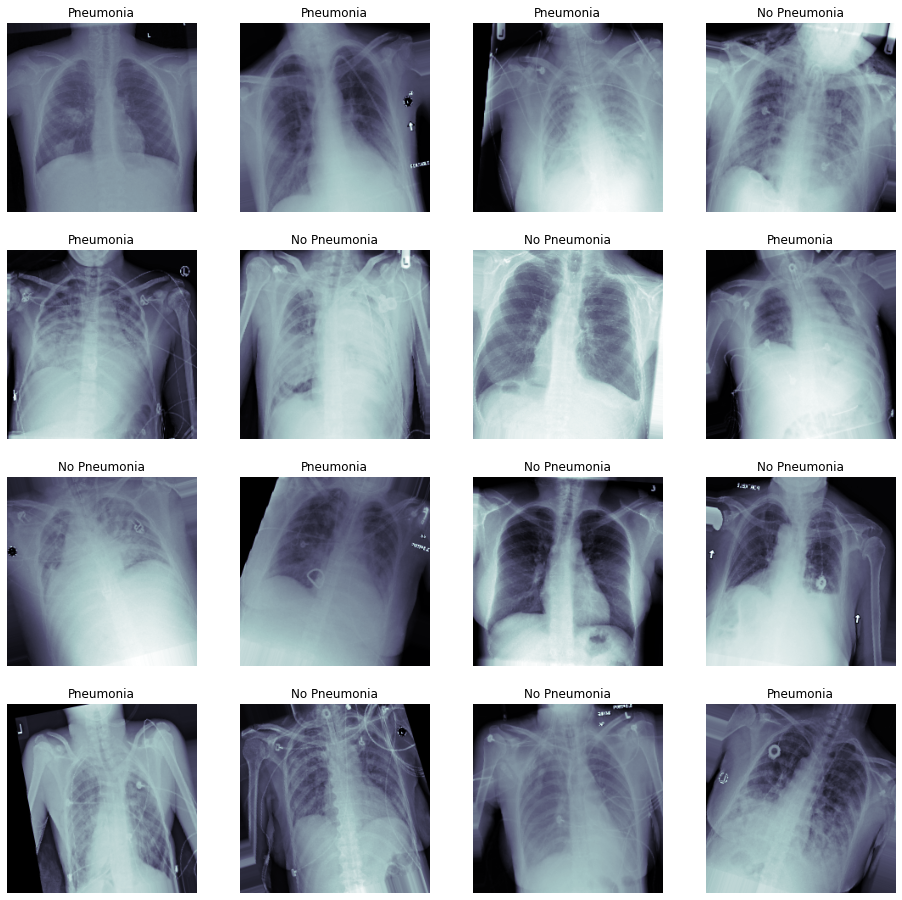

In [11]:
## May want to look at some examples of our augmented training data. 
## This is helpful for understanding the extent to which data is being manipulated prior to training, 
## and can be compared with how the raw data look prior to augmentation

t_x, t_y = next(train_gen)
fig, m_axs = plt.subplots(4, 4, figsize = (16, 16))
for (c_x, c_y, c_ax) in zip(t_x, t_y, m_axs.flatten()):
    c_ax.imshow(c_x[:,:,0], cmap = 'bone')
    if c_y == 1: 
        c_ax.set_title('Pneumonia')
    else:
        c_ax.set_title('No Pneumonia')
    c_ax.axis('off')

## Build your model: 

Recommendation here to use a pre-trained network downloaded from Keras for fine-tuning

In [12]:
def load_pretrained_model():
    
    # model = VGG16(include_top=True, weights='imagenet')
    # transfer_layer = model.get_layer(lay_of_interest)
    # vgg_model = Model(inputs = model.input, outputs = transfer_layer.output)
    
    model = VGG16(include_top=True, weights='imagenet')
    transfer_layer = model.get_layer('block5_pool')
    vgg_model = Model(inputs=model.input,
                       outputs=transfer_layer.output)

    for layer in vgg_model.layers[0:17]:
        layer.trainable = False  
    
    return vgg_model


In [13]:
def build_my_model():
    
    # my_model = Sequential()
    # ....add your pre-trained model, and then whatever additional layers you think you might
    # want for fine-tuning (Flatteen, Dense, Dropout, etc.)
    
    # if you want to compile your model within this function, consider which layers of your pre-trained model, 
    # you want to freeze before you compile 
    
    # also make sure you set your optimizer, loss function, and metrics to monitor
    
    # Todo
    my_model = Sequential()

    # Add the convolutional part of the pretrained model.
    pretrainedModel = load_pretrained_model()
    my_model.add(pretrainedModel)
    
    # Flatten the output of the VGG16 model because it is from a
    # convolutional layer.
    my_model.add(Flatten())

    # Add a dropout-layer which may prevent overfitting and
    # improve generalization ability to unseen data e.g. the test-set.
    my_model.add(Dropout(0.5))

    # Add a dense (aka. fully-connected) layer.
    # This is for combining features that the VGG16 model has
    # recognized in the image.
    my_model.add(Dense(1024, activation='relu'))

    # Add a dropout-layer which may prevent overfitting and
    # improve generalization ability to unseen data e.g. the test-set.
    my_model.add(Dropout(0.5))

    # Add a dense (aka. fully-connected) layer.
    # This is for combining features that the VGG16 model has
    # recognized in the image.
    my_model.add(Dense(512, activation='relu'))

    # Add a dropout-layer which may prevent overfitting and
    # improve generalization ability to unseen data e.g. the test-set.
    my_model.add(Dropout(0.5))

    # Add a dense (aka. fully-connected) layer.
    # This is for combining features that the VGG16 model has
    # recognized in the image.
    my_model.add(Dense(256, activation='relu'))

    # Add a dense (aka. fully-connected) layer.
    # Change the activation function to sigmoid 
    # so output of the last layer is in the range of [0,1] 
    my_model.add(Dense(1, activation='sigmoid'))
    
    optimizer = Adam(lr=2e-4)
    loss = 'binary_crossentropy'
    metrics = ['binary_accuracy']
    my_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return my_model



## STAND-OUT Suggestion: choose another output layer besides just the last classification layer of your modele
## to output class activation maps to aid in clinical interpretation of your model's results

In [14]:
## Below is some helper code that will allow you to add checkpoints to your model,
## This will save the 'best' version of your model by comparing it to previous epochs of training

## Note that you need to choose which metric to monitor for your model's 'best' performance if using this code. 
## The 'patience' parameter is set to 10, meaning that your model will train for ten epochs without seeing
## improvement before quitting

# Todo

# weight_path="{}_my_model.best.hdf5".format('xray_class')

# checkpoint = ModelCheckpoint(weight_path, 
#                              monitor= CHOOSE_METRIC_TO_MONITOR_FOR_PERFORMANCE, 
#                              verbose=1, 
#                              save_best_only=True, 
#                              mode= CHOOSE_MIN_OR_MAX_FOR_YOUR_METRIC, 
#                              save_weights_only = True)

# early = EarlyStopping(monitor= SAME_AS_METRIC_CHOSEN_ABOVE, 
#                       mode= CHOOSE_MIN_OR_MAX_FOR_YOUR_METRIC, 
#                       patience=10)

# callbacks_list = [checkpoint, early]

weight_path="{}_my_model.best.hdf5".format('xray_class')

# Monitor a training loss for this task since the validation loss is very fluctuated in this task
checkpoint = ModelCheckpoint(weight_path, 
                             monitor= 'loss', 
                             verbose=1, 
                             save_best_only=True, 
                             mode= 'min', 
                             save_weights_only = True)

early = EarlyStopping(monitor= 'loss', 
                      mode= 'min', 
                      patience=10)

reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.25,
                                  patience=3, min_lr=1e-5)

callbacks_list = [checkpoint, early, reduce_lr]

### Start training! 

In [15]:
my_model = build_my_model()
my_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
model_1 (Model)              (None, 7, 7, 512)         14714688  
_________________________________________________________________
flatten_1 (Flatten)          (None, 25088)             0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 25088)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 1024)              25691136  
_________________________________________________________________
dropout_2 (Dropout)          (None, 1024)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 512)               524800    
_________________________________________________________________
dropout_3 (Dropout)          (None, 512)              

In [16]:
## train your model



history = my_model.fit_generator(train_gen, 
                          validation_data = (valX, valY), 
                          epochs = 150, 
                          callbacks = callbacks_list)

Epoch 1/150
18/18 [==============================] - 56s 3s/step - loss: 0.7915 - binary_accuracy: 0.5149 - val_loss: 0.6557 - val_binary_accuracy: 0.6484

Epoch 00001: loss improved from inf to 0.79212, saving model to xray_class_my_model.best.hdf5
Epoch 2/150
18/18 [==============================] - 51s 3s/step - loss: 0.7179 - binary_accuracy: 0.5288 - val_loss: 0.6836 - val_binary_accuracy: 0.5625

Epoch 00002: loss improved from 0.79212 to 0.71811, saving model to xray_class_my_model.best.hdf5
Epoch 3/150
18/18 [==============================] - 51s 3s/step - loss: 0.6955 - binary_accuracy: 0.5555 - val_loss: 0.7088 - val_binary_accuracy: 0.5234

Epoch 00003: loss improved from 0.71811 to 0.69511, saving model to xray_class_my_model.best.hdf5
Epoch 4/150
18/18 [==============================] - 51s 3s/step - loss: 0.6964 - binary_accuracy: 0.5511 - val_loss: 0.6493 - val_binary_accuracy: 0.6016

Epoch 00004: loss did not improve from 0.69511
Epoch 5/150
18/18 [====================

18/18 [==============================] - 51s 3s/step - loss: 0.5094 - binary_accuracy: 0.7478 - val_loss: 0.5985 - val_binary_accuracy: 0.6797

Epoch 00035: loss improved from 0.52384 to 0.50913, saving model to xray_class_my_model.best.hdf5
Epoch 36/150
18/18 [==============================] - 51s 3s/step - loss: 0.5076 - binary_accuracy: 0.7509 - val_loss: 0.6668 - val_binary_accuracy: 0.6641

Epoch 00036: loss improved from 0.50913 to 0.50764, saving model to xray_class_my_model.best.hdf5
Epoch 37/150
18/18 [==============================] - 51s 3s/step - loss: 0.5003 - binary_accuracy: 0.7509 - val_loss: 0.7992 - val_binary_accuracy: 0.5547

Epoch 00037: loss improved from 0.50764 to 0.49961, saving model to xray_class_my_model.best.hdf5
Epoch 38/150
18/18 [==============================] - 51s 3s/step - loss: 0.5024 - binary_accuracy: 0.7491 - val_loss: 0.9446 - val_binary_accuracy: 0.5234

Epoch 00038: loss did not improve from 0.49961
Epoch 39/150
18/18 [========================


Epoch 00069: loss improved from 0.28858 to 0.28723, saving model to xray_class_my_model.best.hdf5
Epoch 70/150
18/18 [==============================] - 52s 3s/step - loss: 0.2824 - binary_accuracy: 0.8811 - val_loss: 1.1975 - val_binary_accuracy: 0.6016

Epoch 00070: loss improved from 0.28723 to 0.28195, saving model to xray_class_my_model.best.hdf5
Epoch 71/150
18/18 [==============================] - 51s 3s/step - loss: 0.2793 - binary_accuracy: 0.8855 - val_loss: 1.1139 - val_binary_accuracy: 0.6016

Epoch 00071: loss improved from 0.28195 to 0.27960, saving model to xray_class_my_model.best.hdf5
Epoch 72/150
18/18 [==============================] - 51s 3s/step - loss: 0.2690 - binary_accuracy: 0.8837 - val_loss: 1.0108 - val_binary_accuracy: 0.6328

Epoch 00072: loss improved from 0.27960 to 0.26773, saving model to xray_class_my_model.best.hdf5
Epoch 73/150
18/18 [==============================] - 51s 3s/step - loss: 0.2653 - binary_accuracy: 0.8829 - val_loss: 1.1732 - val_bina


Epoch 00106: loss did not improve from 0.19034
Epoch 107/150
18/18 [==============================] - 51s 3s/step - loss: 0.2180 - binary_accuracy: 0.9087 - val_loss: 1.5522 - val_binary_accuracy: 0.5312

Epoch 00107: loss did not improve from 0.19034
Epoch 108/150
18/18 [==============================] - 51s 3s/step - loss: 0.2109 - binary_accuracy: 0.9087 - val_loss: 1.5448 - val_binary_accuracy: 0.5234

Epoch 00108: loss did not improve from 0.19034
Epoch 109/150
18/18 [==============================] - 51s 3s/step - loss: 0.1931 - binary_accuracy: 0.9139 - val_loss: 1.5276 - val_binary_accuracy: 0.5312

Epoch 00109: loss did not improve from 0.19034
Epoch 110/150
18/18 [==============================] - 52s 3s/step - loss: 0.2067 - binary_accuracy: 0.9156 - val_loss: 1.4861 - val_binary_accuracy: 0.5391

Epoch 00110: loss did not improve from 0.19034
Epoch 111/150
18/18 [==============================] - 54s 3s/step - loss: 0.1981 - binary_accuracy: 0.9156 - val_loss: 1.5582 - val

##### After training for some time, look at the performance of your model by plotting some performance statistics:

Note, these figures will come in handy for your FDA documentation later in the project

In [17]:
## After training, make some predictions to assess your model's overall performance
## Note that detecting pneumonia is hard even for trained expert radiologists, 
## so there is no need to make the model perfect.
my_model.load_weights(weight_path)
pred_Y = my_model.predict(valX, batch_size = 128, verbose = True)

128/128 [==============================] - 1s 7ms/step


In [18]:
def plot_auc(t_y, p_y):
    
    ## Hint: can use scikit-learn's built in functions here like roc_curve
    
    fpr, tpr, _ = sklmet.roc_curve(t_y, p_y)
    roc_auc = sklmet.auc(fpr, tpr)
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
    lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1-Specificity)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()
    
    return

## what other performance statistics do you want to include here besides AUC? 


# def ... 
# Todo

# def ...
# Todo
def plot_precision_recall(t_y, p_y):
    '''
    Plot a Precision-Recall curve and also display the average Precision score
    '''
    fig, c_ax = plt.subplots(1,1, figsize = (9, 9))
    precision, recall, thresholds = sklmet.precision_recall_curve(t_y, p_y)
    c_ax.plot(recall, precision, label = '%s (AP Score:%0.2f)'  % ('Pneumonia', sklmet.average_precision_score(t_y,p_y)))
    c_ax.set_title('Precision-Recall curve')
    c_ax.legend()
    c_ax.set_xlabel('Recall')
    c_ax.set_ylabel('Precision')
    return precision, recall, thresholds  

def calc_f1(prec,recall):
    return 2*(prec*recall)/(prec+recall)

#Also consider plotting the history of your model training:

def plot_history(history):
    fig, m_axs = plt.subplots(1,2, figsize = (12, 4))
    m_axs[0].plot(history.history['loss'], label = "Training Loss")
    m_axs[0].plot(history.history['val_loss'], label = "Validation Loss")
    m_axs[0].set(xlabel='Epoch', ylabel='Loss')
    m_axs[0].set_yscale('log')
    m_axs[0].legend()
    m_axs[0].set_title('Training Loss vs Validation Loss');
    
    m_axs[1].plot(history.history['binary_accuracy'], label = "Training Accuracy")
    m_axs[1].plot(history.history['val_binary_accuracy'], label = "Validation Accuracy")
    m_axs[1].set(xlabel='Epoch', ylabel='Accuracy')
    m_axs[1].legend()
    m_axs[1].set_title('Training Accuracy vs Validation Accuracy');
    return

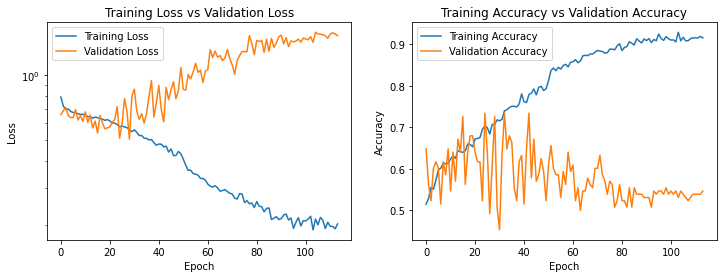

In [19]:
plot_history(history)

Once you feel you are done training, you'll need to decide the proper classification threshold that optimizes your model's performance for a given metric (e.g. accuracy, F1, precision, etc.  You decide) 

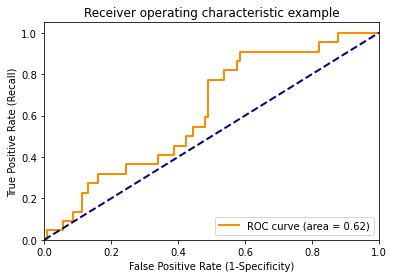

In [20]:
## Find the threshold that optimize your model's performance,
## and use that threshold to make binary classification. Make sure you take all your metrics into consideration.

# ROC Curve
plot_auc(valY, pred_Y)

In highly imbalanced classification problems, ROC AUC can be misleading because the large number of true negatives makes the false positive rate appear small, giving an overly optimistic score. Precision-Recall (PR) curves are often preferred since they focus on precision and recall of the minority positive class.


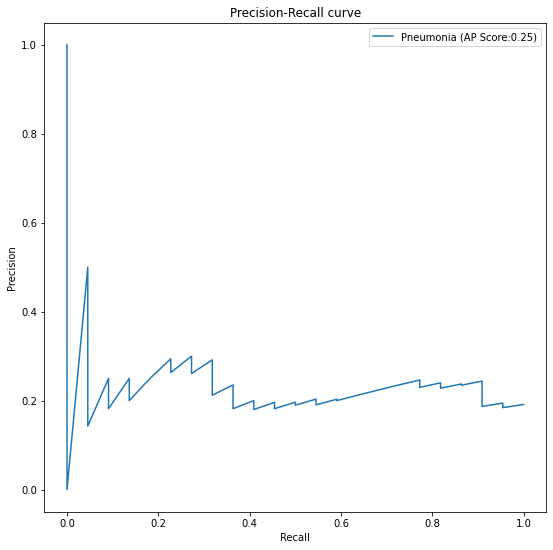

In [21]:
precision, recall, thresholds = plot_precision_recall(valY, pred_Y)

In [22]:
f1_score = calc_f1(precision, recall)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide


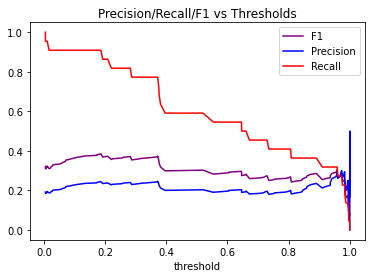

In [23]:
plt.plot(thresholds, f1_score[:-1], color='purple', label="F1")
plt.plot(thresholds, precision[:-1], color='blue', label="Precision")
plt.plot(thresholds, recall[:-1], color='red', label="Recall")

plt.legend()
plt.title('Precision/Recall/F1 vs Thresholds')
plt.xlabel('threshold');

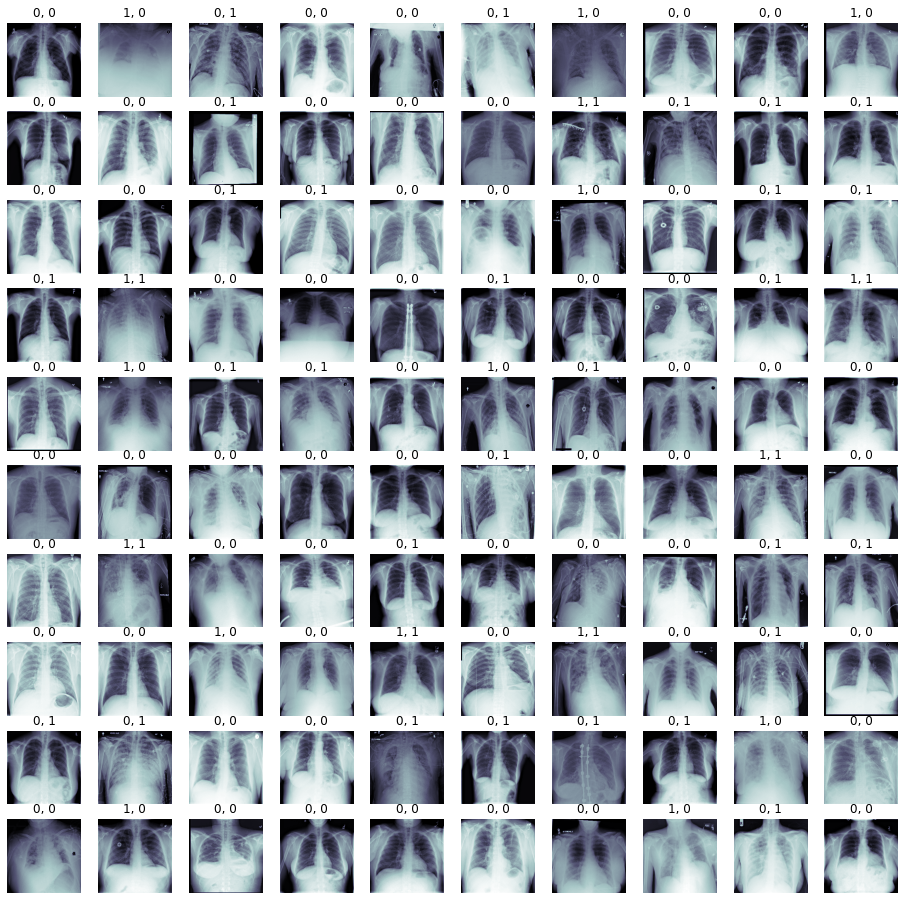

In [24]:
## Let's look at some examples of true vs. predicted with our best model: 
thresh=0.80
# Todo
ground_truth = [] 
p_out = []
fig, m_axs = plt.subplots(10, 10, figsize = (16, 16))
i = 0
for (c_x, c_y, c_ax) in zip(valX[0:100], valY[0:100], m_axs.flatten()):
    ground_truth.append(c_y)
    p_out.append(pred_Y[i] > thresh)
    c_ax.imshow(c_x[:,:,0], cmap = 'bone')
    if c_y == 1: 
        if pred_Y[i] > thresh:
            c_ax.set_title('1, 1')
        else:
            c_ax.set_title('1, 0')
    else:
        if pred_Y[i] > thresh: 
            c_ax.set_title('0, 1')
        else:
            c_ax.set_title('0, 0')
    c_ax.axis('off')
    i=i+1

In [25]:
sklmet.confusion_matrix(ground_truth, p_out)

array([[55, 28],
       [10,  7]])

In [26]:
print('Accuracy: {}'.format(sklmet.balanced_accuracy_score(ground_truth, p_out)))
print('Precision: {}'.format(sklmet.precision_score(ground_truth, p_out)))
print('Recall: {}'.format(sklmet.recall_score(ground_truth, p_out)))
print('F1 Score: {}'.format(sklmet.f1_score(ground_truth, p_out)))

Accuracy: 0.5372076541459958
Precision: 0.2
Recall: 0.4117647058823529
F1 Score: 0.2692307692307692


In [27]:
## Just save model architecture to a .json:

model_json = my_model.to_json()
with open("my_model.json", "w") as json_file:
    json_file.write(model_json)